In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/nasa-cmaps/CMaps/RUL_FD002.txt
/kaggle/input/nasa-cmaps/CMaps/test_FD003.txt
/kaggle/input/nasa-cmaps/CMaps/Damage Propagation Modeling.pdf
/kaggle/input/nasa-cmaps/CMaps/readme.txt
/kaggle/input/nasa-cmaps/CMaps/train_FD003.txt
/kaggle/input/nasa-cmaps/CMaps/test_FD004.txt
/kaggle/input/nasa-cmaps/CMaps/train_FD004.txt
/kaggle/input/nasa-cmaps/CMaps/x.txt
/kaggle/input/nasa-cmaps/CMaps/test_FD002.txt
/kaggle/input/nasa-cmaps/CMaps/train_FD001.txt
/kaggle/input/nasa-cmaps/CMaps/train_FD002.txt
/kaggle/input/nasa-cmaps/CMaps/RUL_FD001.txt
/kaggle/input/nasa-cmaps/CMaps/RUL_FD004.txt
/kaggle/input/nasa-cmaps/CMaps/RUL_FD003.txt
/kaggle/input/nasa-cmaps/CMaps/test_FD001.txt
/kaggle/input/nasa-cmaps/cmaps/CMaps/RUL_FD002.txt
/kaggle/input/nasa-cmaps/cmaps/CMaps/test_FD003.txt
/kaggle/input/nasa-cmaps/cmaps/CMaps/Damage Propagation Modeling.pdf
/kaggle/input/nasa-cmaps/cmaps/CMaps/readme.txt
/kaggle/input/nasa-cmaps/cmaps/CMaps/train_FD003.txt
/kaggle/input/nasa-cmaps/cmaps/CM

In [2]:
# --- TASK 1.1: TẢI DỮ LIỆU-DÙNG TẬP FD001(MÔ PHỎNG ĐIỀU KIỆN VẬN HÀNH ĐƠN GIẢN) ---
import pandas as pd
import numpy as np
# B1. Định nghĩa địa chỉ file
filepath = '/kaggle/input/nasa-cmaps/CMaps/train_FD001.txt'

# B2. Gọi tên cho các cột (26 cột: ID máy, Chu kỳ, 3 chế độ, 21 cảm biến)
cols = ['unit', 'cycle', 'setting1', 'setting2', 'setting3']
sensors = ['s' + str(i) for i in range(1, 22)] # Tạo s1, s2... s21
cols.extend(sensors)

# B3. Đọc file
# sep='\s+' nghĩa là các số cách nhau bằng khoảng trắng
df_train = pd.read_csv(filepath, sep='\s+', header=None, names=cols)

# B4. check 5 dòng đầu tiên
print("=>> Dữ liệu đã tải thành công! Kích thước:", df_train.shape)
df_train.head()

=>> Dữ liệu đã tải thành công! Kích thước: (20631, 26)


,unit,cycle,setting1,setting2,setting3,s1,s2,s3,s4,s5,...,s12,s13,s14,s15,s16,s17,s18,s19,s20,s21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


In [3]:
# --- TASK 1.2: TÍNH TUỔI THỌ CÒN LẠI ---
# B1. Tìm vòng đời lớn nhất (Max Cycle) cho từng cái unit
# gôm nhóm theo 'unit', xong tìm số lớn nhất ở cột 'cycle'
max_cycle = df_train.groupby('unit')['cycle'].max().reset_index()
max_cycle.columns = ['unit', 'max_cycle'] #ta có tên cột là 'max_cycle'

# B2. Ghép cái 'max_cycle' vừa tìm được vào bảng dữ liệu chính
df_train = df_train.merge(max_cycle, on='unit', how='left')

# B3. Tính RUL = Max Cycle - Current Cycle (này là tính tuổi thọ còn lại nè!)
df_train['RUL'] = df_train['max_cycle'] - df_train['cycle']

# B4. Xóa cột 'max_cycle' cho gọn (tại xài xong ròi)
df_train.drop(columns=['max_cycle'], inplace=True)

# B5. Xem kết quả (ĐỂ Ý cột RUL mới xuất hiện ở cuối)
print("=>> Dữ liệu sau khi add cột RUL:")
df_train[['unit', 'cycle', 'RUL']].head()

=>> Dữ liệu sau khi add cột RUL:


,unit,cycle,RUL
0,1,1,191
1,1,2,190
2,1,3,189
3,1,4,188
4,1,5,187


In [4]:
#--- TASK 1.3: BƯỚC CHUẨN HÓA DỮ LIỆU (MinMaxScaler) ---
from sklearn.preprocessing import MinMaxScaler

# B1. Xác định các cột cần chuẩn hóa (Ở đây là 21 cái cảm biến s1 -> s21)
# Bây giờ xài lại cái biến sensor mà mình tạo ở cell đầu tiên:v
cols_normalize = sensors 

# B2. Khởi tạo cái máy "ép" dữ liệu (MinMaxScaler)
scaler = MinMaxScaler()

# 3. Gòi sau đó ép dữ liệu (Fit & Transform)
# Bước này sẽ biến đổi các số to đùng thành số nhỏ xíu xiu từ 0 đến 1
df_train[cols_normalize] = scaler.fit_transform(df_train[cols_normalize])

# B4. Kiểm tra lại hàng họ
print("=>> Dữ liệu sau khi chuẩn hóa (Quan sát các cột s1, s2... ):")
df_train[cols_normalize].head()

=>> Dữ liệu sau khi chuẩn hóa (Quan sát các cột s1, s2... ):


,s1,s2,s3,s4,s5,s6,s7,s8,s9,s10,...,s12,s13,s14,s15,s16,s17,s18,s19,s20,s21
0,0.0,0.183735,0.406802,0.309757,0.0,1.0,0.726248,0.242424,0.109755,0.0,...,0.633262,0.205882,0.199608,0.363986,0.0,0.333333,0.0,0.0,0.713178,0.724662
1,0.0,0.283133,0.453019,0.352633,0.0,1.0,0.628019,0.212121,0.100242,0.0,...,0.765458,0.279412,0.162813,0.411312,0.0,0.333333,0.0,0.0,0.666667,0.731014
2,0.0,0.343373,0.369523,0.370527,0.0,1.0,0.710145,0.272727,0.140043,0.0,...,0.795309,0.220588,0.171793,0.357445,0.0,0.166667,0.0,0.0,0.627907,0.621375
3,0.0,0.343373,0.256159,0.331195,0.0,1.0,0.740741,0.318182,0.124518,0.0,...,0.889126,0.294118,0.174889,0.166603,0.0,0.333333,0.0,0.0,0.573643,0.662386
4,0.0,0.349398,0.257467,0.404625,0.0,1.0,0.668277,0.242424,0.149960,0.0,...,0.746269,0.235294,0.174734,0.402078,0.0,0.416667,0.0,0.0,0.589147,0.704502


In [5]:
# --- XÓA CÁC ĐẶC TRƯNG VÔ NGHĨA/KHÔNG THAY ĐỔI ---(để tối ưu hóa chó cái bảng, nói chung là sẽ chạy mượt mà trơn tru hơn)
# Cái này là yêu cầu trong mục tiêu chí chấm điểm(proper data cleanning)
# B1. Các cột không thay đổi giá trị (constant) hoặc không có ý nghĩa
# Này là danh sách các cột đã được xác minh là không có tác dụng dự đoán trong FD001:
cols_to_drop = [
    'setting3', # Chế độ vận hành này hong thay đổi trong FD001
    's1', 's5', 's10', 's16', 's18', 's19' # Các cảm biến này luôn là hằng số hoặc có giá trị 0
]

# B2. Bước xóa cột khỏi df_train
print("=>> Kích thước df_train trước khi xóa:", df_train.shape)
df_train.drop(columns=cols_to_drop, inplace=True)

# B3. Check lại kích thước:3!
print("    Kích thước df_train sau khi xóa:", df_train.shape)
print("\n=>> Các cột còn lại :")
print(df_train.columns.tolist())

=>> Kích thước df_train trước khi xóa: (20631, 27)
    Kích thước df_train sau khi xóa: (20631, 20)

=>> Các cột còn lại :
['unit', 'cycle', 'setting1', 'setting2', 's2', 's3', 's4', 's6', 's7', 's8', 's9', 's11', 's12', 's13', 's14', 's15', 's17', 's20', 's21', 'RUL']


In [6]:
# --- TASK 1.4: CHIA DỮ LIỆU (TRAIN/TEST SPLIT) ---
from sklearn.model_selection import GroupShuffleSplit

# B1. Xác định: Đầu vào (X) là các cảm biến, Đầu ra (y) là RUL
# Lấy tất cả cột trừ 'unit', 'cycle', 'RUL' ra làm features
features = [col for col in df_train.columns if col not in ['unit', 'cycle', 'RUL']]
X = df_train[features]
y = df_train['RUL']
groups = df_train['unit'] # Cái này là nhìn dô ID máy mà chia nhóm

# B2. Cắt 80% máy để trainning, 20% máy để test nè
gss = GroupShuffleSplit(n_splits=1, train_size=0.80, random_state=42)

for train_idx, test_idx in gss.split(X, y, groups):
    X_train, y_train = X.iloc[train_idx], y.iloc[train_idx]
    X_test, y_test = X.iloc[test_idx], y.iloc[test_idx]

print("=>> ĐÃ CHIA XONGG!")
print(f"-Số máy đi học (Train):  {len(df_train.iloc[train_idx]['unit'].unique())} máy")
print(f"-Số máy đi thi (Test ) :  {len(df_train.iloc[test_idx]['unit'].unique())} máy")

=>> ĐÃ CHIA XONGG!
-Số máy đi học (Train):  80 máy
-Số máy đi thi (Test ) :  20 máy


--- KẾT QUẢ CHỈ SỐ CỦA LINEAR REGRESSION ---
-MAE (Sai số tuyệt đối)   : 30.11 chu kỳ
-RMSE (Sai số bình phương): 38.13 chu kỳ
-R2 Score (Accuracy)      : 0.6626


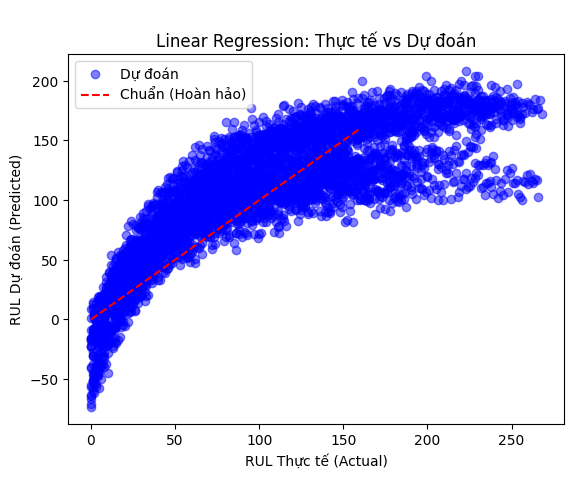

In [7]:
# --- TASK 2.1: LINEAR REGRESSION (Hồi quy Tuyến tính) ---
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt

# B1. Khởi tạo và Dạy học (Fit)
# Khúc này máy sẽ học mối quan hệ giữa các Cảm biến (X_train) và Tuổi thọ (y_train)
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# B2. Cho đi thi thử (Predict trên tập Test)
y_pred_lr = lr_model.predict(X_test)

# B3. Chấm đỉm (Evaluation)
mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = mean_squared_error(y_test, y_pred_lr, squared=False) # Lấy căn bậc 2
r2_lr = r2_score(y_test, y_pred_lr)

print(f"--- KẾT QUẢ CHỈ SỐ CỦA LINEAR REGRESSION ---")
print(f"-MAE (Sai số tuyệt đối)   : {mae_lr:.2f} chu kỳ")
print(f"-RMSE (Sai số bình phương): {rmse_lr:.2f} chu kỳ")
print(f"-R2 Score (Accuracy)      : {r2_lr:.4f}")

# B4. Vẽ biểu đồ so sánh giữa thực tế với dự đoán plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_lr, color='blue', alpha=0.5, label='Dự đoán')
plt.plot([0, 160], [0, 160], color='red', linestyle='--', label='Chuẩn (Hoàn hảo)') # Đường chéo 45 độ
plt.xlabel('RUL Thực tế (Actual)')
plt.ylabel('RUL Dự đoán (Predicted)')
plt.legend()
plt.title('\nLinear Regression: Thực tế vs Dự đoán')# thêm \n để xũn dòng nhìn cho dễ
plt.show()

=>> Đang dò tìm độ sâu (max_depth) tối ưu... pls waitt!! ...

=>> Đã tìm ra tham số peak nhất: {'max_depth': 10, 'n_estimators': 100}

--- KẾT QUẢ CHỈ SỐ CỦA RANDOM FOREST (after optimizze) ---
-MAE (Sai số tuyệt đối)   : 25.87 chu kỳ
-RMSE (Sai số bình phương): 35.33 chu kỳ
-R2 Score (Accuracy)      : 0.7104

 --- TOP 5 CẢM BIẾN QUAN TRỌNG NHẤT: ---
  Sensor  Importance
1    s11    0.582110
2     s9    0.145755
3     s4    0.078826
4    s12    0.038148
5    s14    0.025934


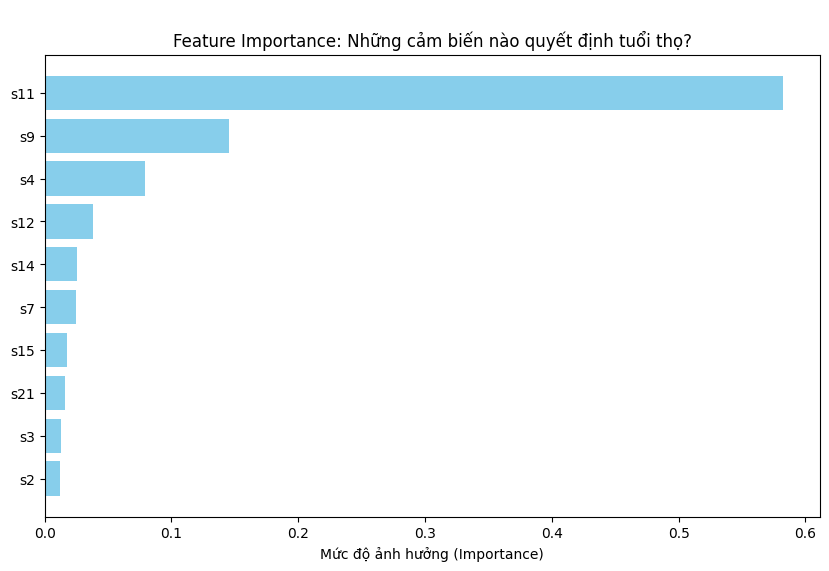

In [8]:
# --- TASK 2.2: RANDOM FOREST ( TUNING:max_depth + FEATURE IMPORTANCE) ---
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.metrics import mean_absolute_error
import pandas as pd
import matplotlib.pyplot as plt

# PHẦN 1: TINH CHỈNH MAX_DEPTH (TUNING)
# B1. Thiết lập lưới tham số để dò tìm
# - n_estimators: 100 cây (chú ý đề yêu cầu 100 cây nha)
# - max_depth: Thử cây cao 10 tầng, 20 tầng, và Không giới hạn (None)
param_grid_rf = {
    'n_estimators': [100],
    'max_depth': [10, 20, None]
}

# B2. Khởi tạo máy dò tìm (GridSearchCV)
print("=>> Đang dò tìm độ sâu (max_depth) tối ưu... pls waitt!! ...")
rf_search = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid_rf,
    cv=3, # Kiểm tra chéo 3 lần cho chắc lunn
    scoring='neg_root_mean_squared_error',
    n_jobs=-1 
)

# B3. Bắt đầu huấn luyện trên tập Train
rf_search.fit(X_train, y_train)

# B4. Lấy ra mô hình xịn nhất (Best Model)
best_rf = rf_search.best_estimator_
print(f"\n=>> Đã tìm ra tham số peak nhất: {rf_search.best_params_}")

# PHẦN 2: ĐÁNH GIÁ MÔ HÌNH (EVALUATION)

# B1. Dùng mô hình xịn nhất để đi thi (Dự đoán trên tập Test)
y_pred_rf = best_rf.predict(X_test)

# B2. Tính điểm số
rmse_rf = mean_squared_error(y_test, y_pred_rf, squared=False)
r2_rf = r2_score(y_test, y_pred_rf)
mae_rf = mean_absolute_error(y_test, y_pred_rf)

print("\n--- KẾT QUẢ CHỈ SỐ CỦA RANDOM FOREST (after optimizze) ---")
print(f"-MAE (Sai số tuyệt đối)   : {mae_rf:.2f} chu kỳ") # Thêm dòng này
print(f"-RMSE (Sai số bình phương): {rmse_rf:.2f} chu kỳ")
print(f"-R2 Score (Accuracy)      : {r2_rf:.4f}")

# PHẦN 3: TRÍCH RA ĐẶC ĐIỂM QUAN TRỌNG (FEATURE IMPORTANCE)

# B1. Lấy độ quan trọng từ mô hình best_rf
importances = best_rf.feature_importances_
feature_names = X_train.columns

# B2. Tạo bảng xếp hạng
feature_imp_df = pd.DataFrame({
    'Sensor': feature_names,
    'Importance': importances
})

# B3. Sắp xếp từ cao xuống thấp
feature_imp_df = feature_imp_df.sort_values(by='Importance', ascending=False).reset_index(drop=True)

print("\n --- TOP 5 CẢM BIẾN QUAN TRỌNG NHẤT: ---")

feature_imp_df.index = range(1, len(feature_imp_df) + 1) #thêm dòng này để nó đánh số thứ tự lại là 1->5(chớ hong nó để 0->4 kì lắm)
print(feature_imp_df.head(5))

# B4. Vẽ biểu đồ 
plt.figure(figsize=(10, 6))
top_10 = feature_imp_df.head(10)
plt.barh(top_10['Sensor'], top_10['Importance'], color='skyblue')
plt.xlabel('Mức độ ảnh hưởng (Importance)')
plt.title('\nFeature Importance: Những cảm biến nào quyết định tuổi thọ?')
plt.gca().invert_yaxis() # khúc này đảo ngược để thằng quan trọng nhất lên đầu nè
plt.show()

In [9]:
# --- TASK 2.3: SVR + TINH CHỈNH THAM SỐ C VÀ EPSILON ---
from sklearn.svm import SVR
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_absolute_error

# 1. Định nghĩa "Lưới" các số muốn thử
# Máy sẽ thử tổ hợp: (C=10, eps=0.1), (C=10, eps=0.2), (C=100, eps=0.1)...
param_grid = {
    'C': [10, 100],          # C càng lớn phạt càng nặng
    'epsilon': [0.1, 0.2]    # Độ rộng ống sai số cho phép
}

# 2. Khởi tạo máy tìm kiếm
# cv=3 nghĩa là mỗi lần thử nó chạy kiểm tra 3 lần cho chắc ăn
print("=>> Đang đi tìm C và epsilon ổn nhất... pls wait!! ...")
svr_search = GridSearchCV(SVR(kernel='rbf'), param_grid, cv=3, verbose=1, n_jobs=-1)

# 3. giờ thì dò tìm trên tập Train
svr_search.fit(X_train, y_train)

# 4. đưa ra kết quả thui
best_svr = svr_search.best_estimator_ # Lấy ra mô hình xịn nhất
print("\n=>> Đã tìm ra! Tham số đỉnh nhất để hoạt động tốt nhất :")
print(svr_search.best_params_)

# 5. ở đây dùng mô hình ngon lành nhất để đi thi (Predict)
y_pred_svr = best_svr.predict(X_test)

# 6. Tính điểm số để in ra độ hiệu quả của mô hình
mae_svr = mean_absolute_error(y_test, y_pred_svr)
rmse_svr = mean_squared_error(y_test, y_pred_svr, squared=False)
r2_svr = r2_score(y_test, y_pred_svr)
print("--- KẾT QUẢ CHỈ SỐ CỦA SVR ---")
print(f"-MAE (Sai số tuyệt đối): {mae_svr:.2f} chu kỳ")
print(f"-RMSE (Sau khi chỉnh)  : {rmse_svr:.2f}")
print(f"-R2 Score              : {r2_svr:.4f}")


=>> Đang đi tìm C và epsilon ổn nhất... pls wait!! ...
Fitting 3 folds for each of 4 candidates, totalling 12 fits

=>> Đã tìm ra! Tham số đỉnh nhất để hoạt động tốt nhất :
{'C': 100, 'epsilon': 0.2}
--- KẾT QUẢ CHỈ SỐ CỦA SVR ---
-MAE (Sai số tuyệt đối): 25.20 chu kỳ
-RMSE (Sau khi chỉnh)  : 35.27
-R2 Score              : 0.7115


In [10]:
# --- TASK 3.1: TÍNH ĐIỂM SỐ CHO CẢ BA MÔ HÌNH (MAE, RMSE, R2) ---
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 1. Khởi tạo danh sách các chỉ số để dễ dàng quản lý
metrics = {}

# 2. Tính toán và lưu trữ chỉ số của TỪNG MÔ HÌNH:

# Linear Regression (LR)
metrics['LR'] = {
    'MAE': mean_absolute_error(y_test, y_pred_lr),
    'RMSE': mean_squared_error(y_test, y_pred_lr, squared=False),
    'R2 Score': r2_score(y_test, y_pred_lr)
}

# Random Forest (RF - đã Tuned)
metrics['RF'] = {
    'MAE': mean_absolute_error(y_test, y_pred_rf),
    'RMSE': mean_squared_error(y_test, y_pred_rf, squared=False),
    'R2 Score': r2_score(y_test, y_pred_rf)
}

# SVR (Đã Tuned)
metrics['SVR'] = {
    'MAE': mean_absolute_error(y_test, y_pred_svr),
    'RMSE': mean_squared_error(y_test, y_pred_svr, squared=False),
    'R2 Score': r2_score(y_test, y_pred_svr)
}

# 3. để khúc này trông đẹp mắt hơn thì chuyển thành Dataframe
results_df = pd.DataFrame(metrics).T # Dùng .T để chuyển hàng thành cột, nhìn dễ so sánh

# 4. Làm tròn số nhìn đẹp và sắp xếp theo RMSE (từ thấp đến cao)
results_df = results_df.round(4)
results_df = results_df.sort_values(by='RMSE', ascending=True)

print(" --- BẢNG TỔNG HỢP CÁC CHỈ SỐ ĐÁNH GIÁ MÔ HÌNH --- ")
print(results_df)

# Ghi chú: Lưu kết quả vào biến global để dùng cho mục 2 và 3
global final_results_df
final_results_df = results_df

 --- BẢNG TỔNG HỢP CÁC CHỈ SỐ ĐÁNH GIÁ MÔ HÌNH --- 
         MAE     RMSE  R2 Score
SVR  25.1986  35.2653    0.7115
RF   25.8746  35.3284    0.7104
LR   30.1113  38.1325    0.6626


In [11]:
# --- TASK 3.2: LẬP BẢNG SO SÁNH VÀ ĐÁNH GIÁ MẠNH YẾU ---

# 1. Lấy lại cái bảng kết quả từ bước trước
# (Dùng .copy() để không làm hỏng dữ liệu gốc)
bang_so_sanh = results_df.copy()

# 2. Thêm cột "Đánh giá" để chỉ mặt xem ai mạnh ai yếu
# Cách làm dân dã: Dùng hàm apply đơn giản
def danh_gia_model(row):
    # Tìm xem RMSE của dòng hiện tại có phải là nhỏ nhất (Min) hay lớn nhất (Max) hong
    if row['RMSE'] == bang_so_sanh['RMSE'].min():
        return "  Mạnh nhất (Best)"
    elif row['RMSE'] == bang_so_sanh['RMSE'].max():
        return "  Yếu nhất (Worst)"
    else:
        return "  Trung bình(normal)"

# Áp dụng hàm trên vào bảng
bang_so_sanh['Xếp hạng'] = bang_so_sanh.apply(danh_gia_model, axis=1)

# 3. Sắp xếp lại: Ai mạnh nhất cho lên đầu ngồi
bang_so_sanh = bang_so_sanh.sort_values(by='RMSE', ascending=True)

print("--- BẢNG SO SÁNH ĐIỂM SỐ 3 MÔ HÌNH ---")
print(bang_so_sanh)



--- BẢNG SO SÁNH ĐIỂM SỐ 3 MÔ HÌNH ---
         MAE     RMSE  R2 Score              Xếp hạng
SVR  25.1986  35.2653    0.7115      Mạnh nhất (Best)
RF   25.8746  35.3284    0.7104    Trung bình(normal)
LR   30.1113  38.1325    0.6626      Yếu nhất (Worst)


 --- BIỂU ĐỒ CỘT ĐẶC TRƯNG THEO TASK 2.2 ĐÃ ĐƯA RA --- 


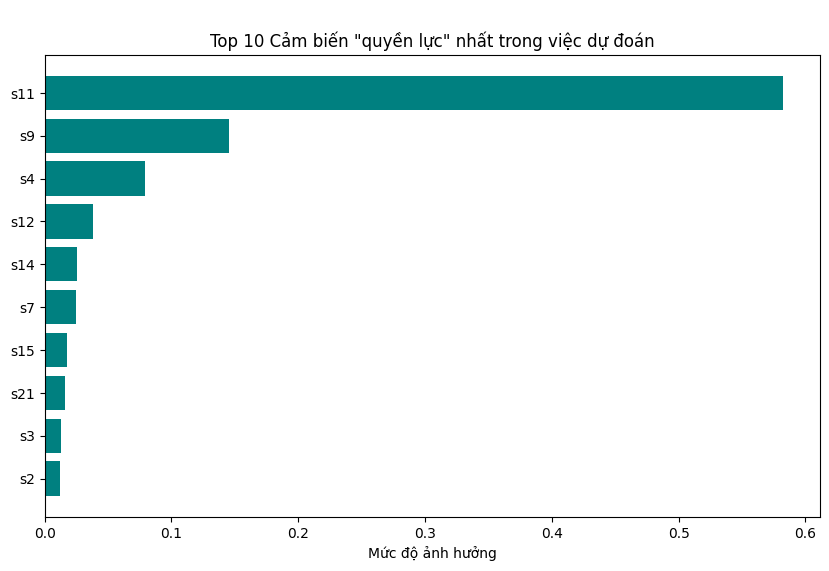

In [12]:
# --- TASK 3.3: Biểu đồ cột thể hiện FEATURE IMPORTANCE (TỪ RANDOM FOREST) ---
import pandas as pd
import matplotlib.pyplot as plt

# 1. Lấy dữ liệu độ quan trọng từ cái cây mình đã trồng (best_rf)
do_quan_trong = best_rf.feature_importances_
ten_cot = X_train.columns

# 2. gom chung vô một bảng để dễ quan sát
bang_quan_trong = pd.DataFrame({
    'Ten_Cam_Bien': ten_cot,
    'Do_Quan_Trong': do_quan_trong
})

# 3. phần này sắp xếp ai quan trọng thì mình cho lên đầu
bang_quan_trong = bang_quan_trong.sort_values(by='Do_Quan_Trong', ascending=False)

# 4. Vẽ biểu đồ
top_10 = bang_quan_trong.head(10) #lấy 10 thằng đầu tiên hoiii
print(" --- BIỂU ĐỒ CỘT ĐẶC TRƯNG THEO TASK 2.2 ĐÃ ĐƯA RA --- ")
plt.figure(figsize=(10, 6))
#này là vẽ cột nằm ngang
plt.barh(top_10['Ten_Cam_Bien'], top_10['Do_Quan_Trong'], color='teal') 
plt.xlabel('Mức độ ảnh hưởng')
plt.title('\nTop 10 Cảm biến "quyền lực" nhất trong việc dự đoán')
plt.gca().invert_yaxis() # Đảo ngược trục Y để cái quan trọng nhất nằm trên cùng
plt.show()

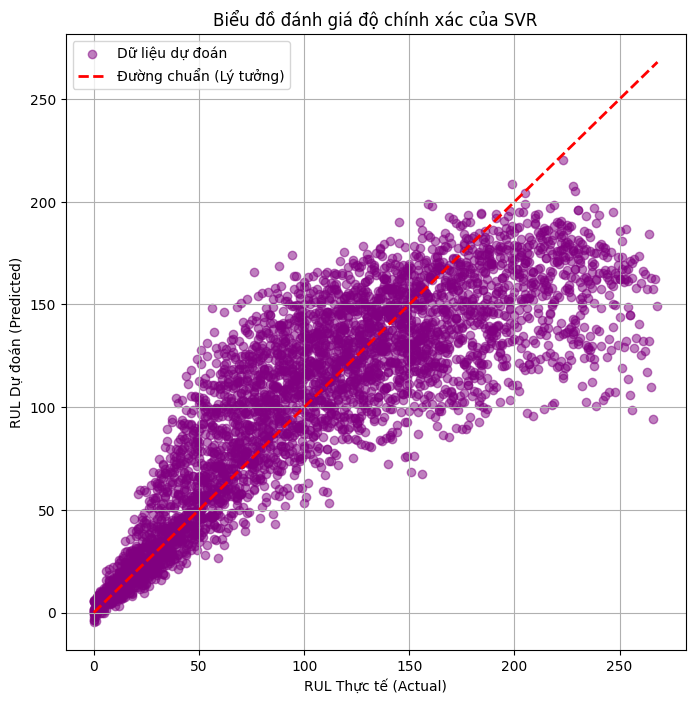

In [13]:
# --- TASK 3.4: VẼ BIỂU ĐỒ DỰ ĐOÁN CỦA MÔ HÌNH TỐT NHẤT (SVR) ---

# 1. Chuẩn bị dữ liệu vẽ
# Mình so sánh giữa Thực tế (y_test) và Dự đoán của SVR (y_pred_svr)
thuc_te = y_test
du_doan = y_pred_svr

# 2. Vẽ hình
plt.figure(figsize=(8, 8)) # Khung hình vuông cho cân đối

# Vẽ các điểm dự đoán (màu tím mộng mơ)
plt.scatter(thuc_te, du_doan, color='purple', alpha=0.5, label='Dữ liệu dự đoán')

# Vẽ đường chuẩn "hoàn hảo" (đường chéo màu đỏ)
# Nếu điểm nào nằm trên đường này nghĩa là đoán trúng phóc 100%
plt.plot([thuc_te.min(), thuc_te.max()], [thuc_te.min(), thuc_te.max()], 
         color='red', linestyle='--', linewidth=2, label='Đường chuẩn (Lý tưởng)')

# 3. Trang trí
plt.xlabel('RUL Thực tế (Actual)')
plt.ylabel('RUL Dự đoán (Predicted)')
plt.title('Biểu đồ đánh giá độ chính xác của SVR')
plt.legend() # Hiện chú thích
plt.grid(True) # Kẻ ô lưới
plt.show()